# Hugging Face Graph Dataset Preprocessing for QuVINE

This notebook helps you:

1. Download a graph dataset from the Hugging Face Hub (`graphs-datasets` ecosystem)
2. Convert it into a clean undirected NetworkX graph
3. Extract repeated **connected induced subgraphs** of approximately **5k–20k nodes**
4. Use a degree-aware sampling heuristic to better preserve the original degree distribution
5. Save sampled subgraphs as edge lists and metadata for downstream QuVINE processing

## Design choices

- **Preferred loader**: Hugging Face `datasets`
- **Fallback path**: generic conversion from common edge-list / edge-index style fields
- **Sampling goal**: connected, induced, degree-aware, repeated multiple times (e.g. 5 or 10 replicas)
- **Output format**: CSV edgelists + JSON metadata

## Notes

- Some Hugging Face graph datasets expose graph content in slightly different schemas.
- The notebook is written to be adaptable: inspect the dataset schema first, then configure the parser.
- The degree-preservation step here is heuristic, not an exact constrained optimization.


## 1. Environment and imports

Install missing packages if needed. Uncomment the next cell if your environment does not already have them.

In [190]:
# %pip install datasets huggingface_hub pandas networkx numpy matplotlib scipy tqdm

In [191]:
from __future__ import annotations

import json
import math
from collections import Counter, deque
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm


## 2. Configuration

Set the dataset identifier and parser hints here.

Because the exact Hugging Face dataset schema can vary, start by loading a small preview and inspect the keys.

In [192]:
DATASET_ID = "graphs-datasets/twitch_egos"
DATASET_CONFIG = None          # e.g. "default" or a named subset
DATASET_SPLIT = None          # will auto-detect available splits; set explicitly if needed (e.g. "train", "test", "validation")
GRAPH_INDEX = 0               # which graph example to use if dataset has multiple graph records

# Output location
OUTPUT_DIR = Path("/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sampling settings
TARGET_SIZES = [5000, 10000, 20000]
REPEATS = 30                   # set to 10 if desired
BASE_SEED = 42

# Degree-aware sampling heuristic settings
RESTART_PROB = 0.15
FRONTIER_WIDTH = 256
DEGREE_WEIGHT_POWER = 0.5     # >0 prefers higher-degree anchors somewhat
LOCAL_BFS_EXPANSION = 8

# Parser hints
# If your dataset entry is edge-list-like, set these to the right keys after preview.
EDGE_SOURCE_KEY = None
EDGE_TARGET_KEY = None

# If your dataset uses edge_index style, set this key after preview.
EDGE_INDEX_KEY = None

# Optional node id column if the edge endpoints are indices into a node table.
NODE_ID_KEY = None


## 3. Load and inspect the Hugging Face dataset

In [193]:
# Auto-detect split if not specified
if DATASET_SPLIT is None:
    # Load dataset info to check available splits
    from datasets import get_dataset_config_names, get_dataset_split_names
    try:
        available_splits = get_dataset_split_names(DATASET_ID, DATASET_CONFIG)
        print(f"Available splits: {available_splits}")
        # Prefer 'train' if available, otherwise use the first split
        if 'train' in available_splits:
            DATASET_SPLIT = 'train'
        elif available_splits:
            DATASET_SPLIT = available_splits[0]
        else:
            # No splits, load entire dataset
            DATASET_SPLIT = None
        print(f"Using split: {DATASET_SPLIT}")
    except Exception as e:
        print(f"Could not detect splits: {e}")
        print("Attempting to load without specifying split...")
        DATASET_SPLIT = None

# Load the dataset
if DATASET_SPLIT is not None:
    dataset = load_dataset(DATASET_ID, DATASET_CONFIG, split=DATASET_SPLIT)
else:
    # Load without split parameter
    dataset_dict = load_dataset(DATASET_ID, DATASET_CONFIG)
    # If it's a DatasetDict, take the first available split
    if hasattr(dataset_dict, 'keys'):
        first_split = list(dataset_dict.keys())[0]
        print(f"Dataset has splits: {list(dataset_dict.keys())}")
        print(f"Using first split: {first_split}")
        dataset = dataset_dict[first_split]
    else:
        dataset = dataset_dict

print(dataset)
print("Number of rows:", len(dataset))
sample_record = dataset[GRAPH_INDEX]
print("Sample keys:", list(sample_record.keys()))
sample_record

Available splits: ['full']
Using split: full
Dataset({
    features: ['edge_index', 'y', 'num_nodes'],
    num_rows: 127094
})
Number of rows: 127094
Sample keys: ['edge_index', 'y', 'num_nodes']


{'edge_index': [[0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   2,
   3,
   3,
   3,
   4,
   4,
   4,
   4,
   5,
   5,
   6,
   6,
   7,
   7,
   8,
   9,
   10,
   10,
   10,
   10,
   10,
   11,
   11,
   12,
   12,
   12,
   13,
   14,
   15,
   16,
   16,
   17,
   17,
   17,
   17,
   17,
   18,
   19,
   19,
   20,
   20,
   20,
   20,
   21,
   21,
   22,
   23,
   23,
   23,
   23,
   23,
   24,
   24,
   25,
   25,
   26,
   27,
   28,
   29,
   30,
   30,
   30,
   30,
   30,
   31,
   31,
   31,
   31,
   32,
   32,
   32,
   32,
   33,
   34,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35,
   35],
  [5,
   17,
   21,
   23,
   24,
   31,
   32,
   35,
   4,
   10,
   12,
   20,
   35,
   35,
   6,
   16,
   35,
   1,
   10,
   30,
   35,
   0,
   35,
   3

## 4. Graph conversion helpers

The helpers below try to support several common Hugging Face graph encodings:

- two parallel edge endpoint arrays (`source`, `target` style)
- one `edge_index` style field shaped like `[2, num_edges]`
- a nested `edges` table with `source` / `target`

The result is converted into a clean undirected simple graph and reduced to its largest connected component.

In [194]:
def _to_python_list(x):
    if x is None:
        return None
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    try:
        return list(x)
    except TypeError:
        return x


def materialize_undirected_simple_graph(G: nx.Graph) -> nx.Graph:
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(G.edges(data=True))
    H.remove_edges_from(nx.selfloop_edges(H))
    return H


def keep_largest_connected_component(G: nx.Graph) -> nx.Graph:
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G.copy()
    lcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc_nodes).copy()


def build_graph_from_parallel_edge_arrays(sources, targets) -> nx.Graph:
    sources = _to_python_list(sources)
    targets = _to_python_list(targets)
    if sources is None or targets is None:
        raise ValueError("sources/targets cannot be None")
    if len(sources) != len(targets):
        raise ValueError("source and target arrays have different lengths")
    G = nx.Graph()
    G.add_edges_from(zip(sources, targets))
    return materialize_undirected_simple_graph(G)


def build_graph_from_edge_index(edge_index) -> nx.Graph:
    edge_index = np.asarray(edge_index)
    if edge_index.ndim != 2:
        raise ValueError(f"edge_index must be 2D, got shape {edge_index.shape}")
    if edge_index.shape[0] == 2:
        src, dst = edge_index[0], edge_index[1]
    elif edge_index.shape[1] == 2:
        src, dst = edge_index[:, 0], edge_index[:, 1]
    else:
        raise ValueError(f"Unrecognized edge_index shape: {edge_index.shape}")
    return build_graph_from_parallel_edge_arrays(src.tolist(), dst.tolist())


def infer_graph_from_record(record: Dict) -> nx.Graph:
    if EDGE_SOURCE_KEY is not None and EDGE_TARGET_KEY is not None:
        G = build_graph_from_parallel_edge_arrays(record[EDGE_SOURCE_KEY], record[EDGE_TARGET_KEY])
        return keep_largest_connected_component(G)

    if EDGE_INDEX_KEY is not None:
        G = build_graph_from_edge_index(record[EDGE_INDEX_KEY])
        return keep_largest_connected_component(G)

    # Try common conventions automatically.
    common_parallel = [
        ("source", "target"),
        ("src", "dst"),
        ("node1", "node2"),
        ("u", "v"),
    ]
    for s_key, t_key in common_parallel:
        if s_key in record and t_key in record:
            G = build_graph_from_parallel_edge_arrays(record[s_key], record[t_key])
            return keep_largest_connected_component(G)

    common_edge_index_keys = ["edge_index", "edges_index", "edge_idx"]
    for key in common_edge_index_keys:
        if key in record:
            G = build_graph_from_edge_index(record[key])
            return keep_largest_connected_component(G)

    if "edges" in record:
        edges_obj = record["edges"]
        if isinstance(edges_obj, dict):
            if "source" in edges_obj and "target" in edges_obj:
                G = build_graph_from_parallel_edge_arrays(edges_obj["source"], edges_obj["target"])
                return keep_largest_connected_component(G)
            if "src" in edges_obj and "dst" in edges_obj:
                G = build_graph_from_parallel_edge_arrays(edges_obj["src"], edges_obj["dst"])
                return keep_largest_connected_component(G)

    raise ValueError(
        "Could not infer graph schema automatically. Set EDGE_SOURCE_KEY / EDGE_TARGET_KEY or EDGE_INDEX_KEY."
    )


In [195]:
G_full = infer_graph_from_record(sample_record)
print(nx.info(G_full) if hasattr(nx, 'info') else (G_full.number_of_nodes(), G_full.number_of_edges()))
print("Connected:", nx.is_connected(G_full))
print("Nodes:", G_full.number_of_nodes())
print("Edges:", G_full.number_of_edges())

(36, 61)
Connected: True
Nodes: 36
Edges: 61


## 5. Degree-distribution diagnostics

In [196]:
def graph_degree_array(G: nx.Graph) -> np.ndarray:
    if G.number_of_nodes() == 0:
        return np.array([], dtype=float)
    return np.array([d for _, d in G.degree()], dtype=float)


def summarize_graph(G: nx.Graph) -> Dict[str, float]:
    deg = graph_degree_array(G)
    return {
        "num_nodes": int(G.number_of_nodes()),
        "num_edges": int(G.number_of_edges()),
        "avg_degree": float(deg.mean()) if len(deg) else 0.0,
        "median_degree": float(np.median(deg)) if len(deg) else 0.0,
        "max_degree": float(deg.max()) if len(deg) else 0.0,
        "num_connected_components": int(nx.number_connected_components(G)),
    }


def plot_degree_ccdf(graphs: Dict[str, nx.Graph], title: str = "Degree CCDF comparison"):
    plt.figure(figsize=(7, 5))
    for label, G in graphs.items():
        deg = graph_degree_array(G)
        deg = deg[deg > 0]
        if len(deg) == 0:
            continue
        xs = np.sort(np.unique(deg))
        ccdf = np.array([(deg >= x).mean() for x in xs])
        plt.step(xs, ccdf, where="post", label=label)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree")
    plt.ylabel("CCDF")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def degree_histogram_distance(G_ref: nx.Graph, G_sub: nx.Graph, bins: int = 30) -> float:
    deg_ref = graph_degree_array(G_ref)
    deg_sub = graph_degree_array(G_sub)
    if len(deg_ref) == 0 or len(deg_sub) == 0:
        return float("inf")
    upper = max(float(deg_ref.max()), float(deg_sub.max()), 1.0)
    bin_edges = np.linspace(0.0, upper, bins + 1)
    h_ref, _ = np.histogram(deg_ref, bins=bin_edges, density=True)
    h_sub, _ = np.histogram(deg_sub, bins=bin_edges, density=True)
    return float(np.abs(h_ref - h_sub).sum())


full_summary = summarize_graph(G_full)
full_summary

{'num_nodes': 36,
 'num_edges': 61,
 'avg_degree': 3.388888888888889,
 'median_degree': 2.0,
 'max_degree': 35.0,
 'num_connected_components': 1}

## 6. Connected induced subgraph sampling

### Heuristic

The sampler below uses a degree-aware frontier expansion strategy:

1. Pick an anchor node with probability weighted by degree
2. Grow a connected set using a frontier
3. Score candidate frontier nodes using:
   - internal connectivity to the current sample
   - closeness of node degree to a degree target drawn from the full graph
   - a small exploration / restart mechanism
4. Materialize the **induced** subgraph on the selected nodes
5. Keep the largest connected component if needed

This is not exact degree-sequence matching, but it works well as a practical preprocessing notebook heuristic.

In [197]:
def induce_subgraph_by_nodes(G: nx.Graph, nodes: Iterable) -> nx.Graph:
    node_set = set(nodes)
    H = nx.Graph()
    H.add_nodes_from((n, G.nodes[n]) for n in node_set)
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if u in node_set and v in node_set)
    return H


def weighted_choice_without_replacement(items, weights, k, rng):
    items = list(items)
    weights = np.asarray(weights, dtype=float)
    if len(items) == 0:
        return []
    if np.all(weights <= 0):
        weights = np.ones(len(items), dtype=float)
    weights = np.maximum(weights, 1e-12)
    probs = weights / weights.sum()
    k_eff = min(k, len(items))
    idx = rng.choice(len(items), size=k_eff, replace=False, p=probs)
    return [items[i] for i in idx]


def sample_anchor_node(G: nx.Graph, rng: np.random.Generator, power: float = 0.5):
    nodes = list(G.nodes())
    deg = np.array([G.degree(n) for n in nodes], dtype=float)
    weights = np.power(np.maximum(deg, 1.0), power)
    weights = weights / weights.sum()
    return nodes[int(rng.choice(len(nodes), p=weights))]


def sample_degree_targets(G: nx.Graph, sample_size: int, rng: np.random.Generator) -> np.ndarray:
    deg = graph_degree_array(G)
    if len(deg) == 0:
        return np.zeros(sample_size)
    return rng.choice(deg, size=sample_size, replace=True)


def connected_degree_aware_subgraph(
    G: nx.Graph,
    target_size: int,
    rng: np.random.Generator,
    restart_prob: float = 0.15,
    degree_weight_power: float = 0.5,
    frontier_width: int = 256,
    local_bfs_expansion: int = 8,
) -> nx.Graph:
    if target_size >= G.number_of_nodes():
        return materialize_undirected_simple_graph(G)

    anchor = sample_anchor_node(G, rng, power=degree_weight_power)
    selected = [anchor]
    selected_set = {anchor}
    frontier = set(G.adj[anchor].keys())

    degree_targets = sample_degree_targets(G, target_size, rng)
    target_ptr = 0

    while len(selected) < target_size:
        if not frontier or rng.random() < restart_prob:
            seed_from_selected = selected[int(rng.integers(0, len(selected)))]
            local_frontier = deque([seed_from_selected])
            steps = 0
            while local_frontier and steps < local_bfs_expansion:
                u = local_frontier.popleft()
                nbrs = list(G.adj[u].keys())
                rng.shuffle(nbrs)
                for v in nbrs:
                    if v not in selected_set:
                        frontier.add(v)
                        local_frontier.append(v)
                steps += 1

        if not frontier:
            remaining = list(set(G.nodes()) - selected_set)
            if not remaining:
                break
            candidate = remaining[int(rng.integers(0, len(remaining)))]
            frontier.add(candidate)

        frontier_list = list(frontier)
        if len(frontier_list) > frontier_width:
            frontier_list = weighted_choice_without_replacement(
                frontier_list,
                [max(G.degree(n), 1) for n in frontier_list],
                frontier_width,
                rng,
            )

        target_degree = degree_targets[min(target_ptr, len(degree_targets) - 1)]
        scores = []
        for node in frontier_list:
            deg = G.degree(node)
            internal_links = sum((nbr in selected_set) for nbr in G.adj[node].keys())
            degree_match = 1.0 / (1.0 + abs(deg - target_degree))
            score = 2.0 * internal_links + degree_match + 0.25 * np.log1p(deg)
            scores.append(score)

        scores = np.asarray(scores, dtype=float)
        if np.all(scores <= 0):
            scores = np.ones_like(scores)
        probs = scores / scores.sum()
        chosen_idx = int(rng.choice(len(frontier_list), p=probs))
        chosen = frontier_list[chosen_idx]

        selected.append(chosen)
        selected_set.add(chosen)
        frontier.discard(chosen)
        frontier.update(v for v in G.adj[chosen].keys() if v not in selected_set)
        target_ptr += 1

    H = induce_subgraph_by_nodes(G, selected_set)
    H = materialize_undirected_simple_graph(H)
    H = keep_largest_connected_component(H)

    # If taking LCC dropped too many nodes, greedily refill through the boundary.
    while H.number_of_nodes() < target_size and H.number_of_nodes() < G.number_of_nodes():
        current_nodes = set(H.nodes())
        boundary = set()
        for u in current_nodes:
            boundary.update(v for v in G.adj[u].keys() if v not in current_nodes)
        if not boundary:
            break
        boundary = list(boundary)
        rng.shuffle(boundary)
        needed = min(target_size - H.number_of_nodes(), len(boundary))
        current_nodes.update(boundary[:needed])
        H = keep_largest_connected_component(induce_subgraph_by_nodes(G, current_nodes))

    return H


def repeated_connected_subgraph_sampling(
    G: nx.Graph,
    target_sizes: Sequence[int],
    repeats: int,
    base_seed: int = 42,
    restart_prob: float = 0.15,
    degree_weight_power: float = 0.5,
    frontier_width: int = 256,
    local_bfs_expansion: int = 8,
) -> List[Dict]:
    results = []
    for target_size in target_sizes:
        effective_target = min(target_size, G.number_of_nodes())
        for repeat_idx in range(repeats):
            seed = base_seed + 1000 * repeat_idx + int(target_size)
            rng = np.random.default_rng(seed)
            H = connected_degree_aware_subgraph(
                G,
                target_size=effective_target,
                rng=rng,
                restart_prob=restart_prob,
                degree_weight_power=degree_weight_power,
                frontier_width=frontier_width,
                local_bfs_expansion=local_bfs_expansion,
            )
            dist = degree_histogram_distance(G, H)
            results.append({
                "target_size": int(target_size),
                "effective_target_size": int(effective_target),
                "repeat_idx": int(repeat_idx),
                "seed": int(seed),
                "graph": H,
                "summary": summarize_graph(H),
                "degree_hist_l1": float(dist),
            })
    return results


## 7. Run repeated sampling

In [198]:
samples = repeated_connected_subgraph_sampling(
    G_full,
    target_sizes=TARGET_SIZES,
    repeats=REPEATS,
    base_seed=BASE_SEED,
    restart_prob=RESTART_PROB,
    degree_weight_power=DEGREE_WEIGHT_POWER,
    frontier_width=FRONTIER_WIDTH,
    local_bfs_expansion=LOCAL_BFS_EXPANSION,
)

print(f"Generated {len(samples)} sampled subgraphs")
[(s['target_size'], s['repeat_idx'], s['summary']['num_nodes'], s['summary']['num_edges']) for s in samples[:5]]

Generated 90 sampled subgraphs


[(5000, 0, 36, 61),
 (5000, 1, 36, 61),
 (5000, 2, 36, 61),
 (5000, 3, 36, 61),
 (5000, 4, 36, 61)]

## 8. Review sample quality

In [199]:
quality_rows = []
for s in samples:
    row = {
        "target_size": s["target_size"],
        "effective_target_size": s["effective_target_size"],
        "repeat_idx": s["repeat_idx"],
        "seed": s["seed"],
        "degree_hist_l1": s["degree_hist_l1"],
    }
    row.update(s["summary"])
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows).sort_values(["target_size", "repeat_idx"])
quality_df

,target_size,effective_target_size,repeat_idx,seed,degree_hist_l1,num_nodes,num_edges,avg_degree,median_degree,max_degree,num_connected_components
0,5000,36,0,5042,0.0,36,61,3.388889,2.0,35.0,1
1,5000,36,1,6042,0.0,36,61,3.388889,2.0,35.0,1
2,5000,36,2,7042,0.0,36,61,3.388889,2.0,35.0,1
3,5000,36,3,8042,0.0,36,61,3.388889,2.0,35.0,1
4,5000,36,4,9042,0.0,36,61,3.388889,2.0,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...
85,20000,36,25,45042,0.0,36,61,3.388889,2.0,35.0,1
86,20000,36,26,46042,0.0,36,61,3.388889,2.0,35.0,1
87,20000,36,27,47042,0.0,36,61,3.388889,2.0,35.0,1
88,20000,36,28,48042,0.0,36,61,3.388889,2.0,35.0,1


In [200]:
quality_df.groupby("target_size")["degree_hist_l1"].agg(["mean", "std", "min", "max"]).reset_index()

,target_size,mean,std,min,max
0,5000,0.0,0.0,0.0,0.0
1,10000,0.0,0.0,0.0,0.0
2,20000,0.0,0.0,0.0,0.0


In [201]:
best_per_size = (
    quality_df.sort_values("degree_hist_l1")
    .groupby("target_size", as_index=False)
    .first()
)
best_per_size

,target_size,effective_target_size,repeat_idx,seed,degree_hist_l1,num_nodes,num_edges,avg_degree,median_degree,max_degree,num_connected_components
0,5000,36,0,5042,0.0,36,61,3.388889,2.0,35.0,1
1,10000,36,29,39042,0.0,36,61,3.388889,2.0,35.0,1
2,20000,36,4,24042,0.0,36,61,3.388889,2.0,35.0,1


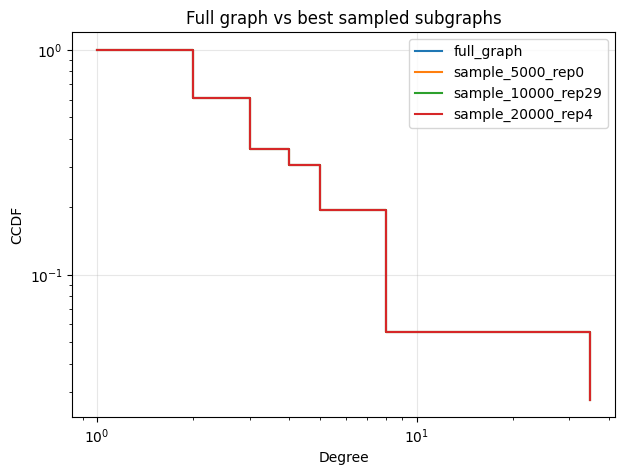

In [202]:
graphs_to_plot = {"full_graph": G_full}
for _, row in best_per_size.iterrows():
    match = [
        s for s in samples
        if s["target_size"] == row["target_size"] and s["repeat_idx"] == row["repeat_idx"]
    ][0]
    graphs_to_plot[f"sample_{int(row['target_size'])}_rep{int(row['repeat_idx'])}"] = match["graph"]

plot_degree_ccdf(graphs_to_plot, title="Full graph vs best sampled subgraphs")

## 9. Save sampled subgraphs for QuVINE

Each sample is saved as:

- `*.csv` edgelist with columns `node1,node2`
- `*.json` metadata with graph statistics and sampling settings


In [203]:
def save_graph_edgelist_csv(G: nx.Graph, path: Path):
    df = pd.DataFrame(list(G.edges()), columns=["node1", "node2"])
    df.to_csv(path, index=False)


def save_sample_bundle(sample: Dict, output_dir: Path, dataset_id: str):
    graph = sample["graph"]
    target_size = sample["target_size"]
    repeat_idx = sample["repeat_idx"]
    stem = f"{dataset_id.replace('/', '__')}_n{target_size}_rep{repeat_idx}"

    csv_path = output_dir / f"{stem}.csv"
    json_path = output_dir / f"{stem}.json"

    save_graph_edgelist_csv(graph, csv_path)
    metadata = {
        "dataset_id": dataset_id,
        "target_size": int(sample["target_size"]),
        "effective_target_size": int(sample["effective_target_size"]),
        "repeat_idx": int(sample["repeat_idx"]),
        "seed": int(sample["seed"]),
        "degree_hist_l1": float(sample["degree_hist_l1"]),
        "summary": sample["summary"],
        "sampling_parameters": {
            "restart_prob": RESTART_PROB,
            "degree_weight_power": DEGREE_WEIGHT_POWER,
            "frontier_width": FRONTIER_WIDTH,
            "local_bfs_expansion": LOCAL_BFS_EXPANSION,
            "base_seed": BASE_SEED,
        },
    }
    with open(json_path, "w") as f:
        json.dump(metadata, f, indent=2)
    return csv_path, json_path


In [204]:
saved_paths = []
for sample in samples:
    saved_paths.append(save_sample_bundle(sample, OUTPUT_DIR, DATASET_ID))

saved_paths[:5]

[(PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep0.csv'),
  PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep0.json')),
 (PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep1.csv'),
  PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep1.json')),
 (PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep2.csv'),
  PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep2.json')),
 (PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-data/huggingface_graph_samples/graphs-datasets__twitch_egos_n5000_rep3.csv'),
  PosixPath('/dccstor/cgq4hls/Q/hugging-graph-processed-

## 10. Optional: keep only the best sample per target size

If you want a single preferred subgraph per target size, use the lowest degree-histogram distance.

In [205]:
best_samples = []
for target_size in sorted(set(s["target_size"] for s in samples)):
    subset = [s for s in samples if s["target_size"] == target_size]
    best = min(subset, key=lambda x: x["degree_hist_l1"])
    best_samples.append(best)

[(s["target_size"], s["repeat_idx"], s["degree_hist_l1"]) for s in best_samples]

[(5000, 0, 0.0), (10000, 0, 0.0), (20000, 0, 0.0)]

## 11. Next steps for QuVINE

Once you save the edgelists, you can:

1. Point QuVINE graph-loading config to one of the saved CSV files
2. Run `prepare_graph(...)` if you want further sparsification/subsampling
3. Evaluate embeddings across multiple repeats of the sampled subgraphs

Example follow-up pattern:

```python
import pandas as pd
import networkx as nx

df = pd.read_csv("../data/processed_data/huggingface_graph_samples/<sample>.csv")
G = nx.from_pandas_edgelist(df, source="node1", target="node2")
print(G.number_of_nodes(), G.number_of_edges())
```
